In [1]:
NOISE_SPECTRUM_PATH = '../config/noise_spectrum.npz'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load(NOISE_SPECTRUM_PATH, allow_pickle=True)

freqs_hz      = d['spectrum_freqs_hz']   # Hz
shape         = d['spectrum_shape']      # normalised amplitude envelope
noise_x       = float(d['noise_param_x'])  # white parallel RMS (ADC)
noise_y       = float(d['noise_param_y'])  # series baseline RMS (ADC)
noise_z       = float(d['noise_param_z'])  # series per-metre RMS (ADC/m)
sampling_mhz  = float(d['sampling_rate_mhz'])
source        = str(d['source'])

freqs_khz = freqs_hz / 1e3
nyquist_khz = sampling_mhz * 1e3 / 2

print(f'Source      : {source}')
print(f'Sampling    : {sampling_mhz} MHz  →  Nyquist = {nyquist_khz:.0f} kHz')
print(f'Freq bins   : {len(freqs_hz)}  ({freqs_hz[0]:.0f} – {freqs_hz[-1]:.0f} Hz)')
print(f'noise_x (white parallel) = {noise_x} ADC')
print(f'noise_y (series baseline) = {noise_y} ADC')
print(f'noise_z (series per-metre) = {noise_z} ADC/m')

Source      : MicroBooNE noise spectra v2 (Plane Y, L=2.330m, amps only), arXiv:1705.07341
Sampling    : 2.0 MHz  →  Nyquist = 1000 kHz
Freq bins   : 101  (0 – 1000000 Hz)
noise_x (white parallel) = 0.9 ADC
noise_y (series baseline) = 0.79 ADC
noise_z (series per-metre) = 0.22 ADC/m


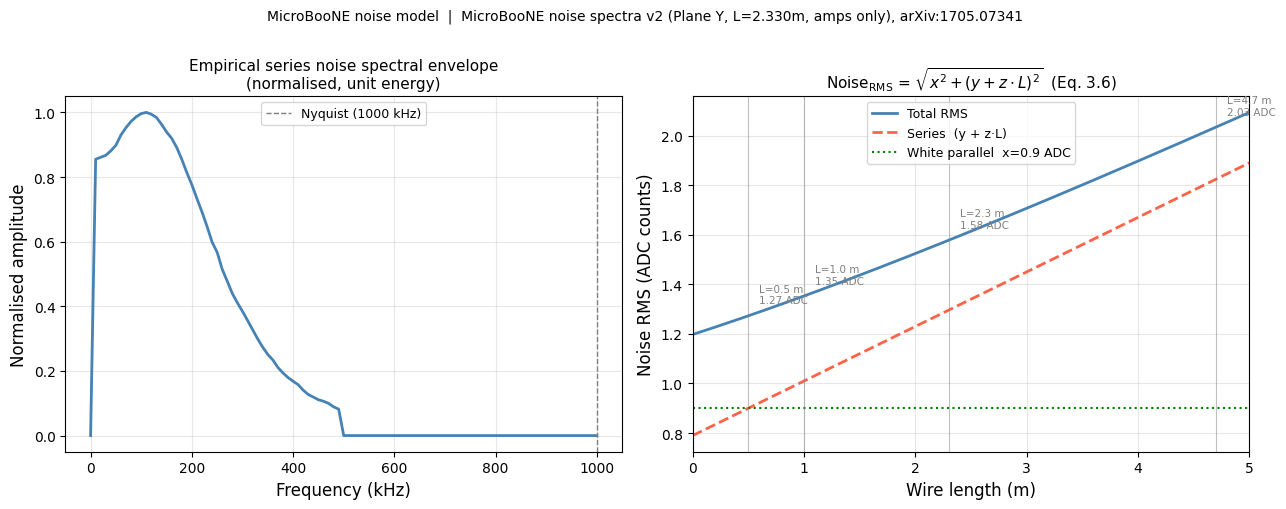

In [3]:
# Example wire lengths for the series RMS scaling
example_lengths_m = [0.5, 1.0, 2.3, 4.7]   # short → longest MicroBooNE wire

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# ── Left: normalised spectral envelope ───────────────────────────────────────
ax = axes[0]
ax.plot(freqs_khz, shape, color='steelblue', lw=2)
ax.axvline(nyquist_khz, color='gray', ls='--', lw=1, label=f'Nyquist ({nyquist_khz:.0f} kHz)')
ax.set_xlabel('Frequency (kHz)', fontsize=12)
ax.set_ylabel('Normalised amplitude', fontsize=12)
ax.set_title('Empirical series noise spectral envelope\n(normalised, unit energy)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Right: total RMS vs wire length ──────────────────────────────────────────
ax2 = axes[1]
L_range = np.linspace(0, 5, 300)
series_rms = noise_y + noise_z * L_range
total_rms  = np.sqrt(noise_x**2 + series_rms**2)

ax2.plot(L_range, total_rms,  color='steelblue',  lw=2, label='Total RMS')
ax2.plot(L_range, series_rms, color='tomato',      lw=2, ls='--', label='Series  (y + z·L)')
ax2.axhline(noise_x, color='green', lw=1.5, ls=':', label=f'White parallel  x={noise_x} ADC')

for L in example_lengths_m:
    rms = float(np.sqrt(noise_x**2 + (noise_y + noise_z * L)**2))
    ax2.axvline(L, color='gray', lw=0.8, ls='-', alpha=0.5)
    ax2.annotate(f'L={L} m\n{rms:.2f} ADC',
                 xy=(L, rms), xytext=(L + 0.1, rms + 0.05),
                 fontsize=7.5, color='gray')

ax2.set_xlabel('Wire length (m)', fontsize=12)
ax2.set_ylabel('Noise RMS (ADC counts)', fontsize=12)
ax2.set_title(
    r'Noise$_\mathrm{RMS}$ = $\sqrt{x^2 + (y + z \cdot L)^2}$  (Eq. 3.6)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 5)

fig.suptitle(f'MicroBooNE noise model  |  {source}', fontsize=10, y=1.01)
fig.tight_layout()
plt.show()